# PCA dos espectros

Este notebook lê os espectros processados, extrai apenas o eixo `y`, monta a matriz de dados e plota um PCA em 2 dimensões.

In [29]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import scienceplots

In [30]:
def load_spectra(folder):
    spectra = []
    names = []

    for filename in sorted(os.listdir(folder)):
        if not filename.endswith(".json"):
            continue

        path = os.path.join(folder, filename)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        y = np.asarray(data["spectrum"]["y"], dtype=float)
        if y.ndim == 2:
            y = y[0]

        spectra.append(y)
        names.append(os.path.splitext(filename)[0])

    return names, np.vstack(spectra)

In [31]:
INPUT_FOLDER = "../data/processed"
names, X = load_spectra(INPUT_FOLDER)

print(f"Arquivos carregados: {len(names)}")
print(f"Formato da matriz: {X.shape}")

Arquivos carregados: 8
Formato da matriz: (8, 1601)


In [32]:
print(X)

[[0.00822155 0.00863822 0.00765693 ... 0.00887476 0.00631576 0.00794821]
 [0.00648339 0.0138315  0.01695559 ... 0.00806755 0.00607226 0.00874638]
 [0.00650326 0.01103845 0.01332252 ... 0.0223219  0.02252154 0.01856032]
 ...
 [0.0535369  0.04720052 0.04336684 ... 0.12532048 0.13078889 0.13111046]
 [0.02617029 0.02442602 0.02285243 ... 0.02966295 0.01951129 0.00736012]
 [0.02903264 0.02818372 0.01862979 ... 0.00740572 0.01313218 0.02663496]]


In [33]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Variância explicada:", pca.explained_variance_ratio_)

Variância explicada: [0.49017055 0.27437596]


In [34]:
color_map = {
    "CeraDePolietileno-633nm": "#1f3db4",
    "CeraDePolietileno-785nm": "#163bb4",

    "PE_glicol_mm10000": "#5f0707",
    "PE_glicol_mm4000": "#c92929",

    "Poliisopreno_trans_633nm": "#43a365",
    "Poliisopreno_trans_785nm": "#3c9b1f",

    "PVA_altaMM": "#e377c2",
    "PVA_mediaMM": "#fd009c"
}

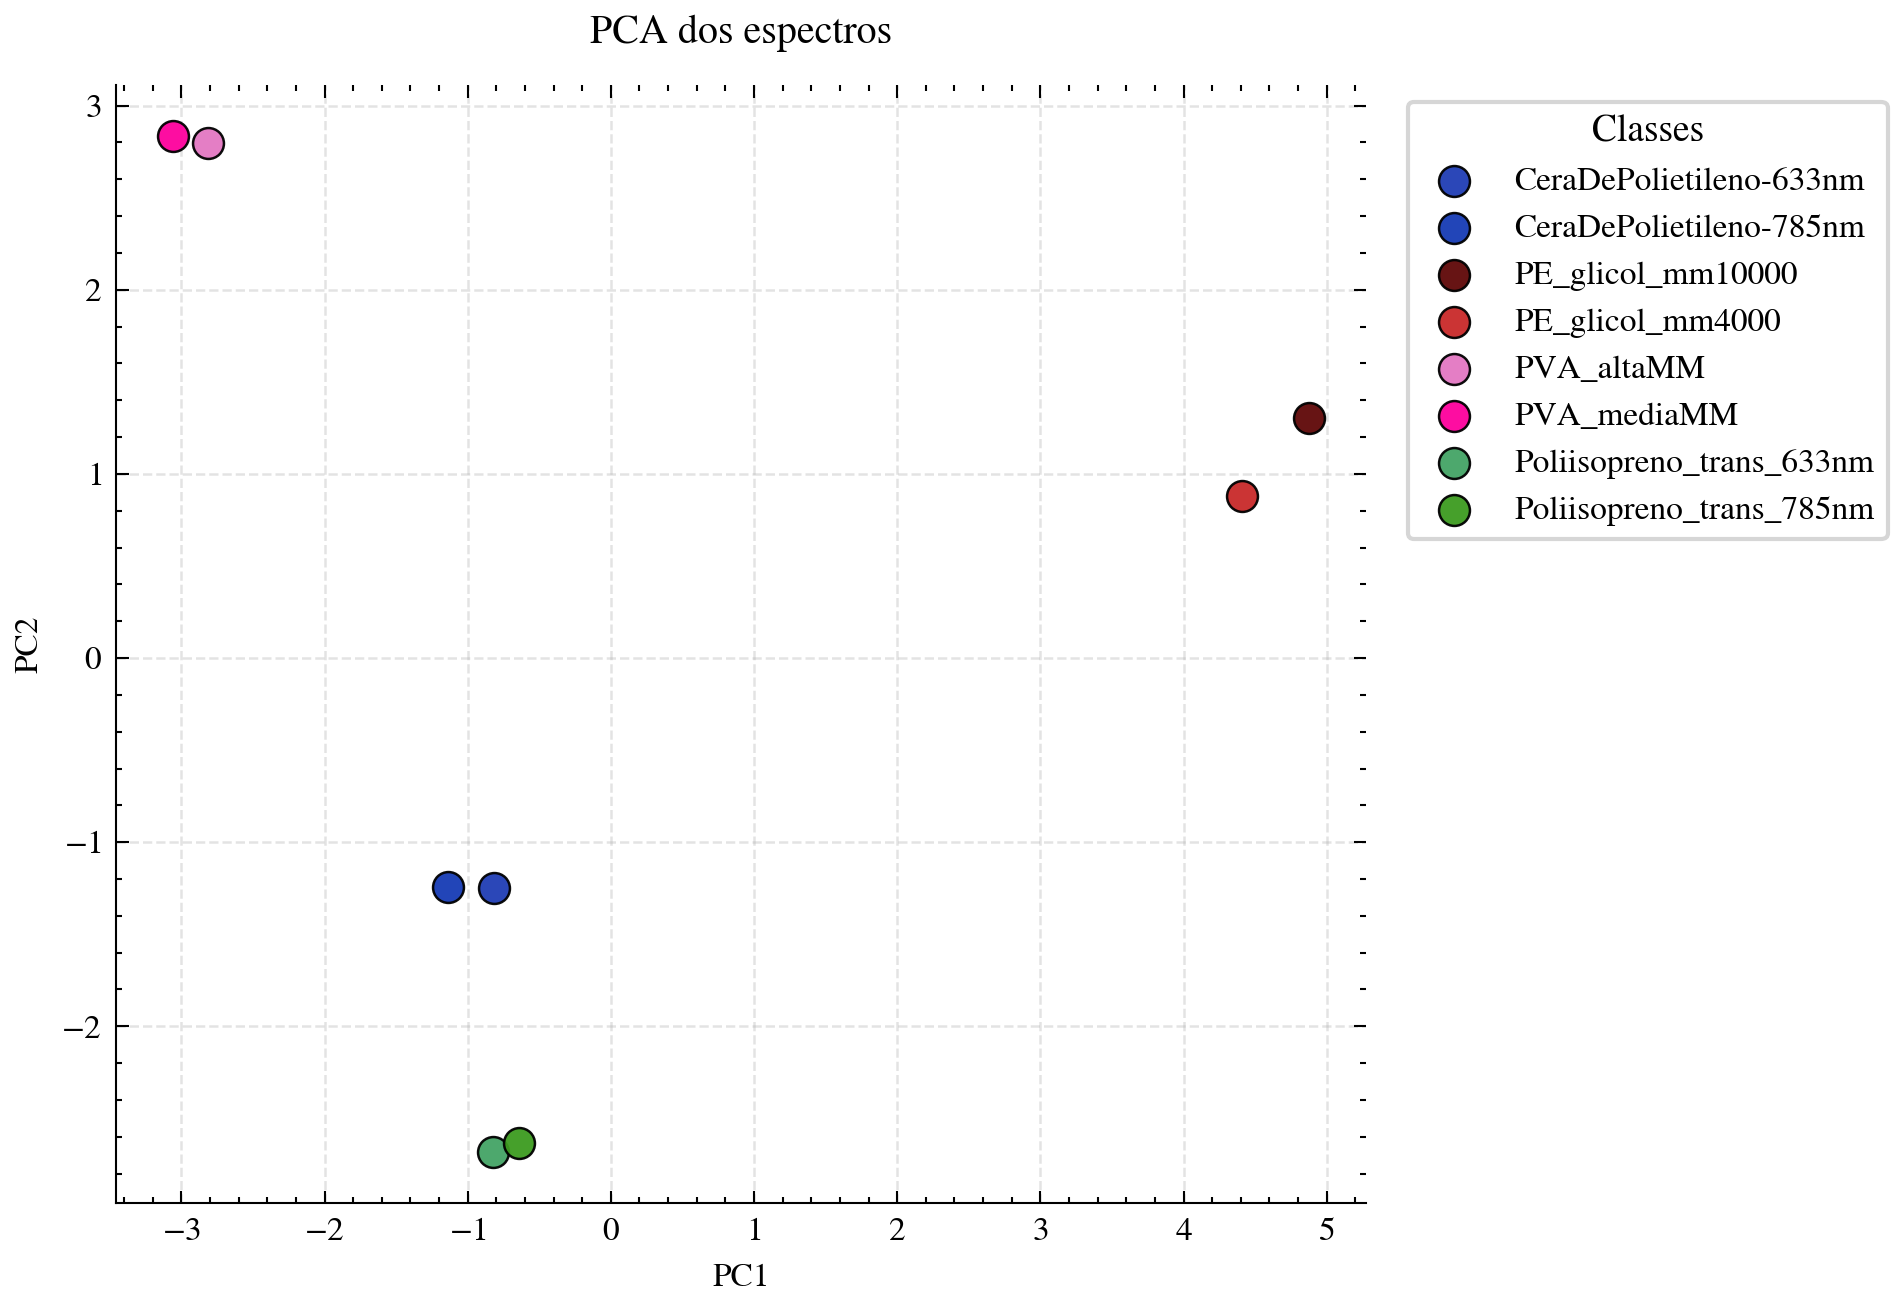

In [35]:
plt.style.use(["science", "ieee", "no-latex"])

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

for name in sorted(set(names)):
    idx = [i for i, n in enumerate(names) if n == name]

    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=name,
        color=color_map.get(name, "0.35"),
        s=55,
        marker="o",
        edgecolors="black",
        linewidths=0.6,
        alpha=0.95,
        zorder=3,
    )

ax.set_title("PCA dos espectros", pad=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Classes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
)

fig.tight_layout()
plt.show()